#### What is the most optimal skill to learn for Data Analysts?
##### Methodology
1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast
import seaborn as sns

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df_DA_India = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')].copy()

df_DA_India = df_DA_India.dropna(subset=['salary_year_avg'])

df_DA_India_exploded = df_DA_India.explode('job_skills')

In [17]:
df_DA_skills = df_DA_India_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})

df_DA_job_count = len(df_DA_India)

In [35]:
df_DA_skills['skills_pecentage'] =100 * df_DA_skills['skill_count']/df_DA_job_count

skill_percent = 11

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skills_pecentage'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skills_pecentage
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
power bi,17,111175.0,18.085106
azure,15,93600.0,15.957447
aws,12,79200.0,12.765957
oracle,11,79200.0,11.702128


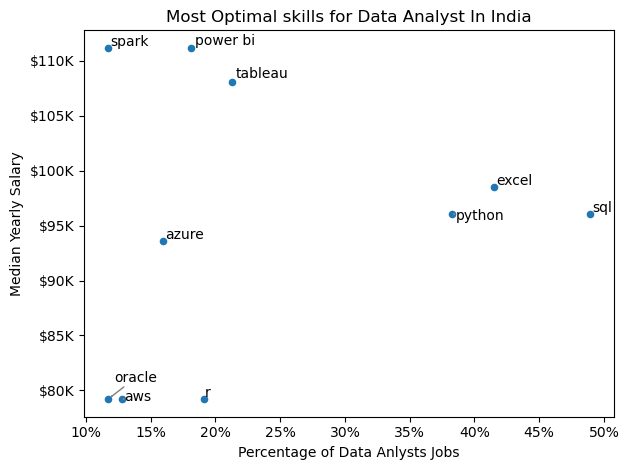

In [38]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter',x='skills_pecentage',y='median_salary')

# prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skills_pecentage'].iloc[i],df_DA_skills_high_demand['median_salary'].iloc[i],txt))

# Adjust text to avoid overlap
adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# set axis labels, title, and legend
plt.xlabel('Percentage of Data Anlysts Jobs')
plt.ylabel('Median Yearly Salary')
plt.title(f'Most Optimal skills for Data Analyst In India')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()


In [ ]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) #convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict: #if key already exists in technology_dict, add value to existing key value pair
            technology_dict[key] += value 
        else: #if key doesn't exists in technology_dict, add key and value 
            technology_dict[key] = value

    # remove duplicates by converting values to set them back to list
    for key, value in technology_dict.items():
        technology_dict[key] = list(set(value))

technology_dict

In [46]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology','skills'])

In [47]:
df_technology = df_technology.explode('skills')

In [48]:
df_technology

,technology,skills
0,analyst_tools,excel
0,analyst_tools,nuix
0,analyst_tools,sharepoint
0,analyst_tools,sheets
0,analyst_tools,qlik
...,...,...
9,sync,zoom
9,sync,unify
9,sync,webex
9,sync,google chat


In [53]:
df_plot = df_DA_skills_high_demand.merge(df_technology,left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skills_pecentage,technology,skills
0,46,96050.0,48.936170,programming,sql
1,39,98500.0,41.489362,analyst_tools,excel
2,36,96050.0,38.297872,programming,python
3,20,108087.5,21.276596,analyst_tools,tableau
4,18,79200.0,19.148936,programming,r
5,17,111175.0,18.085106,analyst_tools,power bi
6,15,93600.0,15.957447,cloud,azure
7,12,79200.0,12.765957,cloud,aws
8,11,79200.0,11.702128,cloud,oracle
9,11,111175.0,11.702128,libraries,spark


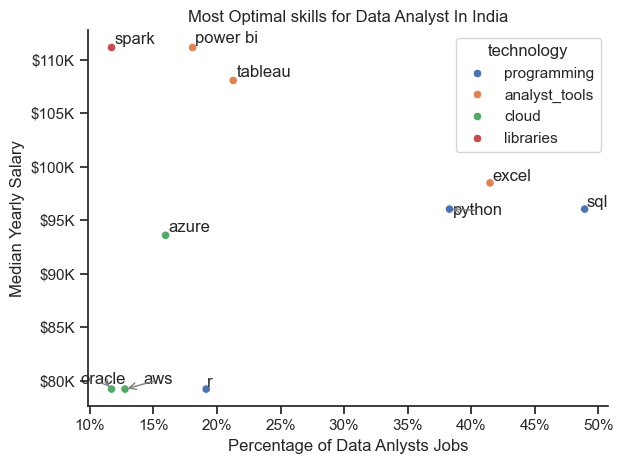

In [ ]:
from adjustText import adjust_text

sns.set_theme(style='ticks')

sns.scatterplot(data=df_plot,x='skills_pecentage',y='median_salary',hue='technology')

sns.despine()
# prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skills_pecentage'].iloc[i],df_DA_skills_high_demand['median_salary'].iloc[i],txt))

# Adjust text to avoid overlap
adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray', lw=1),
    expand_points=(2,2),
    expand_text=(2,2),
    force_text=1.5,
    force_points=1.5)

# set axis labels, title, and legend
plt.xlabel('Percentage of Data Anlysts Jobs')
plt.ylabel('Median Yearly Salary')
plt.title(f'Most Optimal skills for Data Analyst In India')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()
